# Modelagem e Forecasting — Modelos Estatísticos vs Machine Learning

Este notebook tem como objetivo desenvolver, avaliar e comparar diferentes abordagens para previsão da concentração atmosférica de CO₂.

Foram considerados dois grupos principais de modelos:

- **Modelos estatísticos de séries temporais**, capazes de representar diretamente componentes como tendência, sazonalidade e autocorrelação;
- **Modelos de Machine Learning**, utilizando engenharia de atributos para transformar a série temporal em um problema supervisionado.

Ao longo do notebook são avaliados:

- Holt-Winters;
- SARIMAX;
- Random Forest;
- XGBoost.

A comparação entre os modelos é realizada utilizando validação temporal com `TimeSeriesSplit`, preservando a ordem cronológica dos dados e evitando vazamento de informação entre treino e validação.

As métricas utilizadas são:

- MAE;
- RMSE;
- MAPE.

O **MAE** é adotado como principal critério de seleção.

Além da comparação inicial, os modelos de Machine Learning passam por uma etapa de otimização de hiperparâmetros com `RandomizedSearchCV`.

Por fim, o modelo com melhor desempenho é avaliado em um conjunto de teste final reservado, treinado novamente com todo o histórico disponível e utilizado para gerar previsões futuras da série.

# Importando as Bibliotecas

Nesta etapa, são carregadas as bibliotecas necessárias para a construção, validação e comparação dos modelos de séries temporais e Machine Learning.

Serão utilizadas ferramentas para:

* manipulação e visualização dos dados;
* construção de modelos estatísticos de forecasting;
* criação de modelos de Machine Learning;
* validação temporal com `TimeSeriesSplit`;
* otimização de hiperparâmetros;
* cálculo das métricas de desempenho.


In [2]:
# Manipulação e visualização
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Modelos estatísticos
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Métricas
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# Validação e tuning
from sklearn.model_selection import (
    TimeSeriesSplit,
    RandomizedSearchCV
)

# Machine Learning
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


# 1. Leitura e Validação dos Dados

Nesta etapa, o dataset tratado anteriormente é carregado para o notebook de modelagem.

Em seguida, é realizada uma validação rápida para confirmar a estrutura temporal da série, a ausência de valores ausentes e a consistência do índice antes do treinamento dos modelos.

In [3]:
# Fazendo a Leitura da Base de dados tratado
dados = pd.read_csv("../data/co2_clean.csv", index_col=0, parse_dates=True)
dados.head()

,co2
1958-03-29,316.1
1958-04-05,317.3
1958-04-12,317.6
1958-04-19,317.5
1958-04-26,316.4


In [4]:
# Fazendo uma validação rápida

print(f"Classe do Index -> {type(dados.index)}")
print(f"\nShape -> {dados.shape}")

print(f"\nValores Ausentes:\n{dados.isna().sum()}")

print(f"\nOrdenado -> {dados.index.is_monotonic_increasing}")
print(f"Frequência -> {pd.infer_freq(dados.index)}")

print(
    f"\nPeríodo -> "
    f"{dados.index.min().date()} até {dados.index.max().date()}"
)

Classe do Index -> <class 'pandas.DatetimeIndex'>

Shape -> (2284, 1)

Valores Ausentes:
co2    0
dtype: int64

Ordenado -> True
Frequência -> W-SAT

Período -> 1958-03-29 até 2001-12-29


### Observações

O dataset possui **2.284 observações**, sem valores ausentes e com índice do tipo `DatetimeIndex`.

Os registros estão ordenados cronologicamente, com frequência **semanal aos sábados (`W-SAT`)**, cobrindo o período de **1958-03-29 a 2001-12-29**.

Com essas verificações, os dados estão prontos para a próxima etapa de modelagem.

# 2. Divisão dos Dados de Modelagem e Teste Final

A série foi dividida de forma cronológica, preservando a ordem temporal dos dados.

As **últimas 52 semanas** foram reservadas como conjunto de teste final, representando aproximadamente um ano completo e permanecendo fora do processo de seleção dos modelos.

O restante da série será utilizado para treinamento, validação temporal e comparação das diferentes abordagens de forecasting.

In [5]:
semanas = 52

dados_modelagem = dados.iloc[:-semanas].copy()
teste_final = dados.iloc[-semanas:].copy()

Dados Modelagem -> 1958-03-29 até 2000-12-30
Dados Teste Final -> 2001-01-06 até 2001-12-29


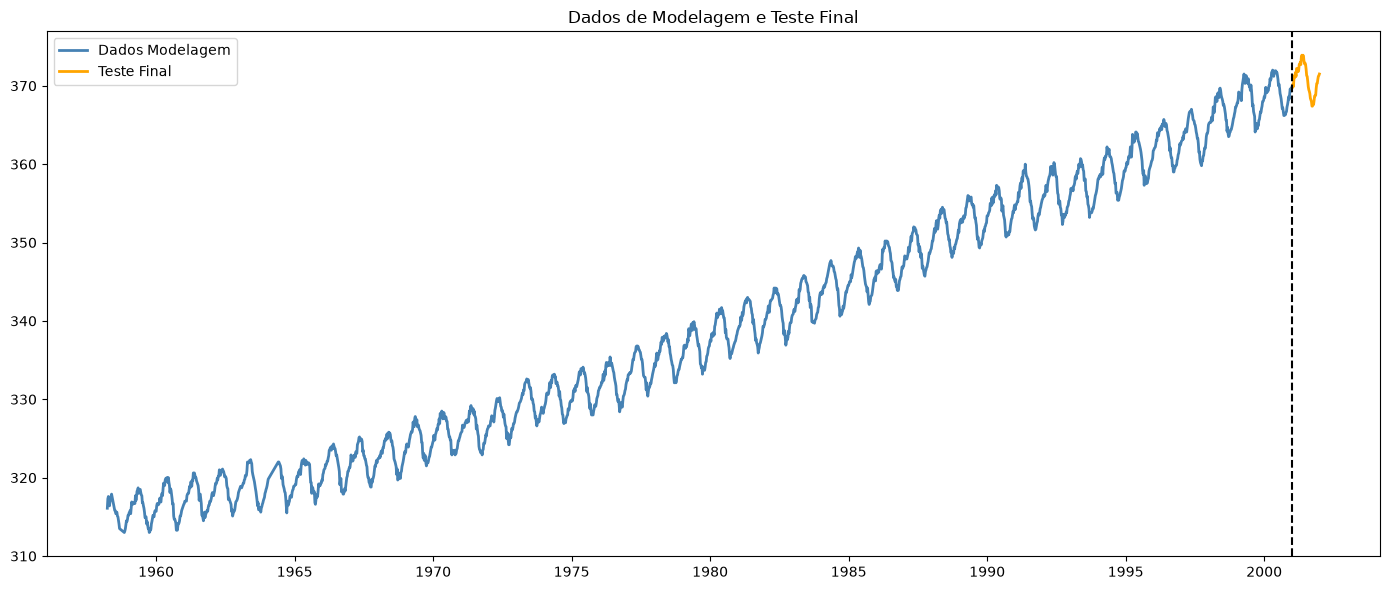

In [6]:
print(f"Dados Modelagem -> {dados_modelagem.index.min().date()} até {dados_modelagem.index.max().date()}")
print(f"Dados Teste Final -> {teste_final.index.min().date()} até {teste_final.index.max().date()}")

plt.figure(figsize=(14,6))
plt.plot(dados_modelagem.index, dados_modelagem.values, color='steelblue', linewidth=2.0, label='Dados Modelagem')
plt.plot(teste_final.index, teste_final.values, color='orange', linewidth=2.0, label='Teste Final')
plt.axvline(teste_final.index[0], color='black', linestyle='--')
plt.legend()
plt.title('Dados de Modelagem e Teste Final')
plt.tight_layout()
plt.show()

### Observações

Os dados de modelagem abrangem o período de **1958-03-29 a 2000-12-30**, enquanto o teste final corresponde ao período de **2001-01-06 a 2001-12-29**.

A separação temporal evita o uso de informações futuras durante o treinamento e mantém o último ciclo anual completamente isolado para a avaliação final do modelo selecionado.

# 3. Definição das Métricas de Avaliação

Para comparar o desempenho dos modelos, foi criada uma função responsável pelo cálculo das principais métricas de erro utilizadas no projeto.

Foram consideradas:

- **MAE (Mean Absolute Error):** mede o erro absoluto médio das previsões;
- **RMSE (Root Mean Squared Error):** penaliza com maior intensidade erros mais elevados;
- **MAPE (Mean Absolute Percentage Error):** representa o erro médio em termos percentuais.

Como todas representam medidas de erro, **valores menores indicam melhor desempenho preditivo**.

In [7]:
def calcular_metricas(y_real, y_previsto):
    mae = mean_absolute_error(y_real, y_previsto)
    rmse = np.sqrt(mean_squared_error(y_real, y_previsto))
    mape = np.mean(np.abs((y_real - y_previsto) / y_real)) * 100

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

# 4. Modelos Estatísticos

Nesta etapa, são avaliados modelos clássicos de séries temporais utilizando validação temporal com `TimeSeriesSplit`.

A estratégia adotada utiliza **5 folds**, com horizonte de **52 semanas** em cada validação, preservando a ordem cronológica da série e simulando diferentes cenários de previsão ao longo do tempo.

## 4.1 Holt-Winters

O primeiro modelo avaliado é o **Holt-Winters**, também conhecido como suavização exponencial tripla.

O modelo foi configurado com componentes aditivos de tendência e sazonalidade, utilizando um período sazonal de **52 semanas**, correspondente aproximadamente a um ciclo anual da série.

Em cada fold, o modelo é treinado utilizando apenas as observações anteriores ao período de validação e realiza a previsão das 52 semanas seguintes.

In [8]:
tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=52
)

resultados_hw = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(dados_modelagem), start=1):

    treino = dados_modelagem.iloc[train_idx]['co2']
    validacao = dados_modelagem.iloc[val_idx]['co2']

    modelo = ExponentialSmoothing(
        treino,
        trend='add',
        seasonal='add',
        seasonal_periods=52
    ).fit()

    previsoes = modelo.forecast(steps=len(validacao))

    metricas = calcular_metricas(validacao, previsoes)

    metricas["Fold"] = fold
    metricas["Modelo"] = "Holt-Winters"

    resultados_hw.append(metricas)

c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\co2-forecasting-statistical-vs-ml\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\co2-forecasting-statistical-vs-ml\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\co2-forecasting-statistical-vs-ml\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\co2-forecasting-statistical-vs-ml\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No fr

## 4.2 SARIMAX

O segundo modelo estatístico avaliado é o **SARIMAX**, capaz de representar simultaneamente dependências temporais regulares e padrões sazonais.

Com base na análise exploratória realizada anteriormente, o modelo foi configurado com:

- ordem não sazonal `(1, 1, 1)`;
- ordem sazonal `(1, 1, 1, 52)`;
- período sazonal de **52 semanas**.

Assim como no Holt-Winters, a avaliação é realizada com `TimeSeriesSplit`, utilizando 5 folds e horizonte de 52 semanas em cada validação.

In [9]:
tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=52
)

resultados_sarimax = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(dados_modelagem), start=1):

    treino = dados_modelagem.iloc[train_idx]['co2']
    validacao = dados_modelagem.iloc[val_idx]['co2']

    modelo = SARIMAX(
        treino,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 52)
    ).fit()

    previsoes = modelo.forecast(steps=len(validacao))

    metricas = calcular_metricas(validacao, previsoes)

    metricas["Fold"] = fold
    metricas["Modelo"] = "SARIMAX"

    resultados_sarimax.append(metricas)

c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\co2-forecasting-statistical-vs-ml\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\co2-forecasting-statistical-vs-ml\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\co2-forecasting-statistical-vs-ml\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\co2-forecasting-statistical-vs-ml\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No fr

### 4.3 Comparação dos Modelos Estatísticos

Após a validação temporal, os resultados do Holt-Winters e do SARIMAX são consolidados para uma comparação inicial.

Para cada modelo, são calculadas a média e o desvio-padrão das métricas **MAE, RMSE e MAPE** ao longo dos diferentes folds.

Essa etapa permite avaliar tanto o desempenho médio quanto a estabilidade dos modelos estatísticos antes da comparação com os modelos de Machine Learning.

In [10]:
resultados_hw = pd.DataFrame(resultados_hw)
resultados_sarimax = pd.DataFrame(resultados_sarimax)

resultados = pd.concat([resultados_hw, resultados_sarimax], ignore_index=True)

comparacao = (resultados.groupby("Modelo")[["MAE", "RMSE", "MAPE"]].agg(["mean", "std"]))

comparacao

MAE                RMSE                MAPE          
                  mean       std      mean       std      mean       std
Modelo                                                                  
Holt-Winters  0.763999  0.332000  0.982502  0.417397  0.208729  0.090953
SARIMAX       0.503870  0.271599  0.621755  0.296449  0.137619  0.074086

# 5. Modelos de Machine Learning

Diferentemente dos modelos estatísticos, os algoritmos de Machine Learning não modelam diretamente a estrutura temporal da série.

Por isso, a série é transformada em um problema supervisionado por meio da criação de variáveis que representam o histórico recente, padrões sazonais e comportamento médio da concentração de CO₂.

## 5.1 Preparação dos Dados para Machine Learning

Nesta etapa, são criadas features temporais a partir da própria série de CO₂.

Foram utilizadas:

- **lags**, representando valores observados em semanas anteriores;
- **médias móveis**, calculadas apenas com informações passadas;
- **variáveis sazonais cíclicas**, representando a posição de cada semana dentro do ciclo anual.

Os lags de 1, 2, 4, 13, 26 e 52 semanas permitem representar dependências de curto, médio e longo prazo.

As médias móveis de 4, 13 e 52 semanas ajudam a capturar o comportamento recente e a tendência local da série.

In [11]:
df_ml = dados.copy()

# Lags
df_ml["lag_1"] = df_ml["co2"].shift(1)
df_ml["lag_2"] = df_ml["co2"].shift(2)
df_ml["lag_4"] = df_ml["co2"].shift(4)
df_ml["lag_13"] = df_ml["co2"].shift(13)
df_ml["lag_26"] = df_ml["co2"].shift(26)
df_ml["lag_52"] = df_ml["co2"].shift(52)

# Médias móveis
df_ml["rolling_mean_4"] = (df_ml["co2"].shift(1).rolling(4).mean())

df_ml["rolling_mean_13"] = (df_ml["co2"].shift(1).rolling(13).mean())

df_ml["rolling_mean_52"] = (df_ml["co2"].shift(1).rolling(52).mean())

# Sazonalidade
df_ml["week_of_year"] = (df_ml.index.isocalendar().week.astype(int))

df_ml["week_sin"] = np.sin(2 * np.pi * df_ml["week_of_year"] / 52)

df_ml["week_cos"] = np.cos(2 * np.pi * df_ml["week_of_year"] / 52)

df_ml.drop(columns="week_of_year", inplace=True)

# Remove observações sem histórico suficiente
df_ml = df_ml.dropna()

In [12]:
df_ml.head()

,co2,lag_1,lag_2,lag_4,lag_13,lag_26,lag_52,rolling_mean_4,rolling_mean_13,rolling_mean_52,week_sin,week_cos
1959-03-28,316.7,316.7,316.75,316.60,315.2,313.333333,316.1,316.7125,316.092308,315.413462,1.000000,-1.608123e-16
1959-04-04,317.7,316.7,316.70,316.80,315.2,313.277778,317.3,316.7375,316.207692,315.425000,0.992709,-1.205367e-01
1959-04-11,317.1,317.7,316.70,316.75,315.5,313.222222,317.6,316.9625,316.400000,315.432692,0.970942,-2.393157e-01
1959-04-18,317.6,317.1,317.70,316.70,315.6,313.166667,317.5,317.0500,316.523077,315.423077,0.935016,-3.546049e-01
1959-04-25,318.3,317.6,317.10,316.70,315.8,313.111111,316.4,317.2750,316.676923,315.425000,0.885456,-4.647232e-01


## 5.2 Preparação dos Dados para Modelagem e Teste Final

Após a criação das features temporais, os dados são separados utilizando a **mesma data de corte adotada nos modelos estatísticos**, mantendo o período final isolado para avaliação posterior.

Em seguida, são definidos os conjuntos de entrada (`X`) e a variável alvo (`y`). As features incluem lags, médias móveis e componentes sazonais, enquanto `co2` representa o valor que será previsto pelos modelos de Machine Learning.

Essa organização garante consistência entre as diferentes abordagens e evita que informações do período de teste sejam utilizadas durante o treinamento.


In [13]:
data_inicio_teste = teste_final.index.min()
print(data_inicio_teste)

2001-01-06 00:00:00


In [14]:
dados_ml_modelagem = df_ml.iloc[df_ml.index < data_inicio_teste].copy()

teste_ml_final = df_ml.iloc[df_ml.index > data_inicio_teste].copy()

print(f"Dados Ml Modelagem -> {dados_ml_modelagem.index.min().date()} até {dados_ml_modelagem.index.max().date()}")
print(f"Teste ML Final -> {teste_ml_final.index.min().date()} até {teste_ml_final.index.max().date()}")

Dados Ml Modelagem -> 1959-03-28 até 2000-12-30
Teste ML Final -> 2001-01-13 até 2001-12-29


In [15]:
FEATURES = ['lag_1','lag_2','lag_4','lag_13','lag_26','lag_52','rolling_mean_4','rolling_mean_13','rolling_mean_52','week_sin','week_cos']

X_modelagem = dados_ml_modelagem[FEATURES]
y_modelagem = dados_ml_modelagem["co2"]

X_teste_final = teste_ml_final[FEATURES]
y_teste_final = teste_ml_final["co2"]

## 5.3 Random Forest

O primeiro modelo de Machine Learning avaliado é o **Random Forest Regressor**, um algoritmo baseado na combinação de múltiplas árvores de decisão.

O modelo é treinado utilizando as features temporais criadas anteriormente e avaliado com a mesma estratégia de validação temporal baseada em `TimeSeriesSplit`.

Em cada fold, o Random Forest utiliza apenas os dados históricos disponíveis para treinamento e realiza previsões sobre a janela de validação seguinte.

In [16]:
resultados_rf = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_modelagem)):
    X_treino = X_modelagem.iloc[train_idx]
    X_val = X_modelagem.iloc[val_idx]

    y_treino = y_modelagem.iloc[train_idx]
    y_val = y_modelagem.iloc[val_idx]

    modelo = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        max_depth=5,
        n_jobs=-1
    )

    modelo.fit(X_treino, y_treino)

    previsoes = modelo.predict(X_val)

    metricas = calcular_metricas(y_val, previsoes)

    metricas['Fold'] = fold
    metricas['Modelo'] = 'Random Forest'

    resultados_rf.append(metricas)

## 5.4 XGBoost

O segundo modelo de Machine Learning avaliado é o **XGBoost Regressor**, um algoritmo de boosting baseado em árvores de decisão construídas sequencialmente.

Assim como no Random Forest, o modelo utiliza as features temporais derivadas da série de CO₂ e é avaliado utilizando `TimeSeriesSplit`, preservando a ordem cronológica dos dados.

As previsões obtidas em cada fold são avaliadas por meio das métricas MAE, RMSE e MAPE para posterior comparação com os demais modelos.

In [17]:
resultados_xgb = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_modelagem)):
    X_treino = X_modelagem.iloc[train_idx]
    X_val = X_modelagem.iloc[val_idx]

    y_treino = y_modelagem.iloc[train_idx]
    y_val = y_modelagem.iloc[val_idx]

    modelo = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=5,
        random_state=42,
        n_jobs=-1
    )

    modelo.fit(X_treino, y_treino)

    previsoes = modelo.predict(X_val)

    metricas = calcular_metricas(y_val, previsoes)

    metricas['Fold'] = fold
    metricas['Modelo'] = 'XGBoost'

    resultados_xgb.append(metricas)

# 6. Comparação Inicial dos Modelos

Após a validação temporal, os resultados dos modelos estatísticos e de Machine Learning são consolidados em uma única tabela.

Para cada modelo, são calculadas a média e o desvio-padrão das métricas **MAE, RMSE e MAPE** ao longo dos folds.

A comparação é ordenada pelo **MAE médio**, adotado como principal métrica de avaliação neste projeto. Como se trata de uma métrica de erro, valores menores indicam melhor desempenho.

In [18]:
resultados_rf = pd.DataFrame(resultados_rf)
resultados_xgb = pd.DataFrame(resultados_xgb)

resultados = pd.concat([resultados_hw, resultados_sarimax, resultados_rf, resultados_xgb], ignore_index=True)

comparacao = (resultados.groupby("Modelo")[["MAE", "RMSE", "MAPE"]].agg(["mean", "std"]).round(3))

comparacao = comparacao.sort_values(
    by=("MAE", "mean"),
    ascending=True
)

comparacao

MAE          RMSE          MAPE       
                mean    std   mean    std   mean    std
Modelo                                                 
SARIMAX        0.504  0.272  0.622  0.296  0.138  0.074
Holt-Winters   0.764  0.332  0.983  0.417  0.209  0.091
XGBoost        0.924  0.295  1.155  0.363  0.252  0.080
Random Forest  1.109  0.414  1.441  0.483  0.302  0.112

### Observações

Nesta primeira comparação, o **SARIMAX apresentou o menor erro médio** entre os modelos avaliados, com melhor desempenho em MAE, RMSE e MAPE.

O Holt-Winters apresentou o segundo melhor resultado, enquanto XGBoost e Random Forest ficaram atrás dos modelos estatísticos.

Esse resultado sugere que, para esta série de CO₂, a estrutura temporal de tendência e sazonalidade foi capturada de forma mais eficiente pelos modelos estatísticos.

Antes da seleção definitiva do modelo, os modelos de Machine Learning serão submetidos a uma etapa de otimização de hiperparâmetros para verificar se ainda é possível melhorar seu desempenho.

# 7. Otimização de Hiperparâmetros com RandomizedSearchCV

Após a comparação inicial dos modelos, os algoritmos de Machine Learning são submetidos a uma etapa de otimização de hiperparâmetros.

Foi utilizado o `RandomizedSearchCV`, que testa diferentes combinações de parâmetros de forma aleatória, reduzindo o custo computacional em relação a uma busca exaustiva.

A validação continua sendo realizada com `TimeSeriesSplit`, preservando a ordem temporal da série.

Como o **MAE** foi definido como a principal métrica de avaliação do projeto, a busca utiliza `neg_mean_absolute_error` como critério de otimização.

Nesta etapa, são ajustados os hiperparâmetros do:

- Random Forest;
- XGBoost.

## 7.1 Tuning do Random Forest

São testadas diferentes combinações relacionadas ao número e à complexidade das árvores, buscando a configuração com menor MAE médio durante a validação temporal.

In [19]:
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

parametros_rf = {
    "n_estimators": [200, 300, 400],
    "max_depth": [3, 5, 10],
    "min_samples_split": [2, 5, 7],
    "min_samples_leaf": [1, 2, 4]
}

busca_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=parametros_rf,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

busca_rf.fit(X_modelagem, y_modelagem)

print(f"Melhores Hiperparãmetros : {busca_rf.best_params_}")
print(f"\n Melhor MAE médio: {-busca_rf.best_score_}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Melhores Hiperparãmetros : {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10}

 Melhor MAE médio: 0.7724483956936209


## 7.2 Tuning do XGBoost

Para o XGBoost, são avaliadas diferentes combinações de número de estimadores, taxa de aprendizado, profundidade das árvores e parâmetros de amostragem.

O objetivo é encontrar uma configuração mais adequada à estrutura temporal representada pelas features construídas anteriormente.

In [20]:
modelo_xgb = xgb.XGBRegressor(
    objective="reg:absoluteerror",
    random_state=42,
    n_jobs=-1
)

parametros_xgb = {
    "n_estimators": [200, 300, 400],
    "learning_rate": [0.05, 0.1, 1],
    "max_depth": [3, 5 , 10],
    "subsample": [0.9, 1.0],
    "colsample_bytree": [0.9, 1.0]
}

busca_xgb = RandomizedSearchCV(
    estimator=modelo_xgb,
    param_distributions=parametros_xgb,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

busca_xgb.fit(X_modelagem, y_modelagem)

print(f"Melhores Hiperparãmetros : {busca_xgb.best_params_}")
print(f"\n Melhor MAE médio: {-busca_xgb.best_score_}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Melhores Hiperparãmetros : {'subsample': 0.9, 'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.9}

 Melhor MAE médio: 0.8270654296875012


# 8. Avaliação dos Modelos Otimizados

Após a etapa de tuning, os melhores hiperparâmetros encontrados para Random Forest e XGBoost são aplicados novamente utilizando validação temporal com `TimeSeriesSplit`.

O objetivo é verificar o desempenho dos modelos ajustados em múltiplas janelas temporais e compará-los com os modelos estatísticos avaliados anteriormente.

As métricas MAE, RMSE e MAPE são calculadas para cada fold e posteriormente consolidadas por média e desvio-padrão.

In [21]:
resultados_rf_tuned = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_modelagem), start=1):

    X_treino = X_modelagem.iloc[train_idx]
    X_val = X_modelagem.iloc[val_idx]

    y_treino = y_modelagem.iloc[train_idx]
    y_val = y_modelagem.iloc[val_idx]

    modelo = RandomForestRegressor(
        **busca_rf.best_params_,
        random_state=42,
        n_jobs=-1
    )

    modelo.fit(X_treino, y_treino)

    previsoes = modelo.predict(X_val)

    metricas = calcular_metricas(y_val, previsoes)

    metricas["Fold"] = fold
    metricas["Modelo"] = "Random Forest Tuned"

    resultados_rf_tuned.append(metricas)

In [22]:
resultados_xgb_tuned = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_modelagem), start=1):

    X_treino = X_modelagem.iloc[train_idx]
    X_val = X_modelagem.iloc[val_idx]

    y_treino = y_modelagem.iloc[train_idx]
    y_val = y_modelagem.iloc[val_idx]

    modelo = xgb.XGBRegressor(
        **busca_xgb.best_params_,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    modelo.fit(X_treino, y_treino)

    previsoes = modelo.predict(X_val)

    metricas = calcular_metricas(y_val, previsoes)

    metricas["Fold"] = fold
    metricas["Modelo"] = "XGBoost Tuned"

    resultados_xgb_tuned.append(metricas)

## 8.1 Comparação Final dos Modelos

Os resultados dos modelos estatísticos e dos modelos de Machine Learning otimizados são consolidados em uma única comparação.

A ordenação é realizada pelo **MAE médio**, definido como principal critério de avaliação do projeto, enquanto RMSE e MAPE são utilizados como métricas complementares.

In [23]:
resultados_rf_tuned = pd.DataFrame(resultados_rf_tuned)
resultados_xgb_tuned = pd.DataFrame(resultados_xgb_tuned)

resultados = pd.concat([resultados_hw, resultados_sarimax, resultados_rf_tuned, resultados_xgb_tuned], ignore_index=True)

comparacao = (resultados.groupby("Modelo")[["MAE", "RMSE", "MAPE"]].agg(["mean", "std"]).round(3))

comparacao = comparacao.sort_values(
    by=("MAE", "mean"),
    ascending=True
)

comparacao

MAE          RMSE          MAPE       
                      mean    std   mean    std   mean    std
Modelo                                                       
SARIMAX              0.504  0.272  0.622  0.296  0.138  0.074
Holt-Winters         0.764  0.332  0.983  0.417  0.209  0.091
Random Forest Tuned  0.772  0.275  0.974  0.318  0.210  0.075
XGBoost Tuned        0.827  0.309  1.052  0.378  0.225  0.084

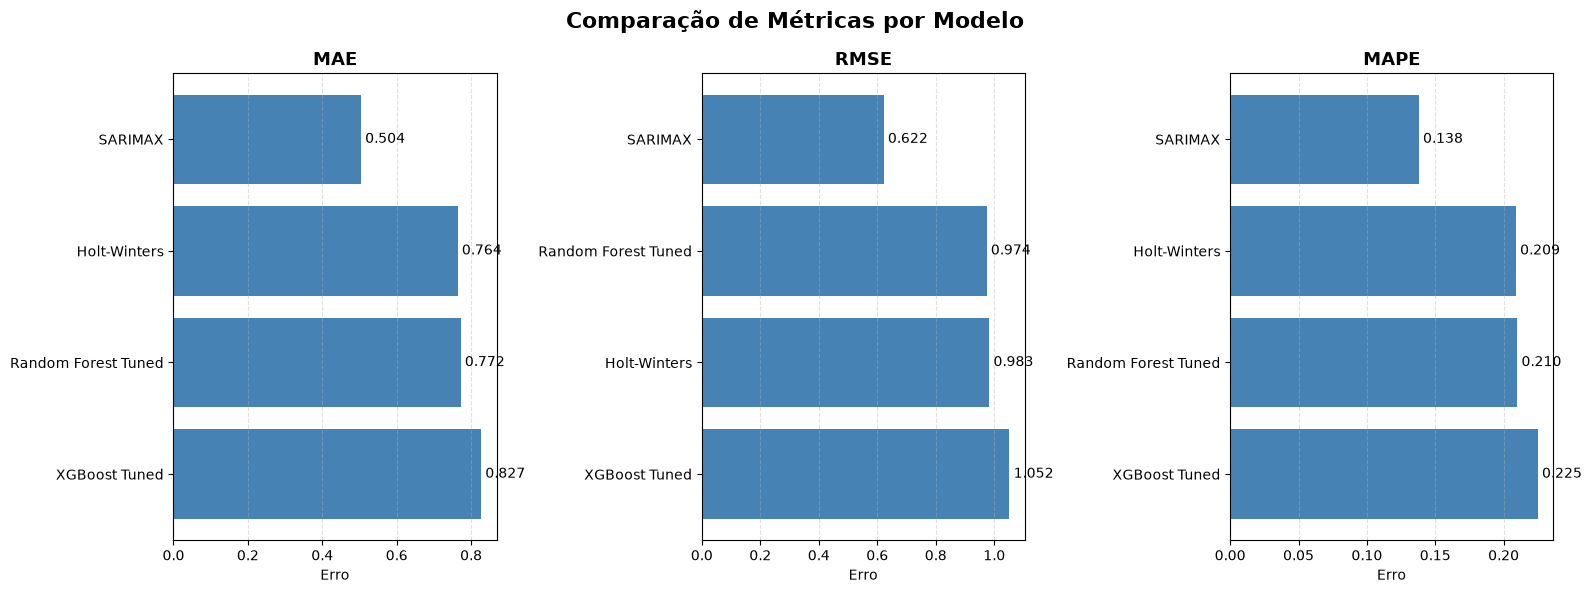

In [24]:
metricas_plot = pd.DataFrame({
    "MAE": comparacao[("MAE", "mean")],
    "RMSE": comparacao[("RMSE", "mean")],
    "MAPE": comparacao[("MAPE", "mean")]
})

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

metricas = ["MAE", "RMSE", "MAPE"]

for ax, metrica in zip(axes, metricas):

    valores = metricas_plot[metrica].sort_values(ascending=False)

    bars = ax.barh(valores.index, valores.values, color="steelblue")

    ax.set_title(metrica, fontsize=13, fontweight="bold")

    ax.set_xlabel("Erro")

    ax.grid(axis="x", linestyle="--", alpha=0.4)

    ax.bar_label(bars, fmt="%.3f", padding=3)

fig.suptitle("Comparação de Métricas por Modelo", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

### Observações

Mesmo após o ajuste de hiperparâmetros, o **SARIMAX apresentou o melhor desempenho geral**, obtendo os menores valores médios de MAE, RMSE e MAPE.

O Holt-Winters e o Random Forest Tuned apresentaram resultados próximos entre si, enquanto o XGBoost Tuned apresentou desempenho inferior aos demais modelos avaliados.

Esse resultado indica que, para esta série temporal univariada, caracterizada por tendência e sazonalidade bem definidas, o modelo estatístico SARIMAX conseguiu representar a estrutura temporal de forma mais eficiente do que os modelos de Machine Learning considerados.

Com base nessa comparação, o SARIMAX é selecionado para a etapa de avaliação no conjunto de teste final.

# 9. Modelo Final — SARIMAX(1,1,1)(1,1,1,52)

Após a comparação entre os modelos, o **SARIMAX** foi selecionado como modelo final por apresentar o melhor desempenho médio durante a validação temporal.

O modelo é treinado utilizando todo o conjunto de dados destinado à modelagem e, em seguida, realiza previsões sobre as **52 semanas reservadas como teste final**.

Essa etapa permite avaliar a capacidade de generalização do modelo em um período completamente separado do processo de seleção.


In [25]:
modelo_final = SARIMAX(
    dados_modelagem['co2'],
    order=(1,1,1),
    seasonal_order=(1,1,1,52)
).fit()

c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\co2-forecasting-statistical-vs-ml\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\co2-forecasting-statistical-vs-ml\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)


In [26]:
previsoes_finais = modelo_final.forecast(
    steps=len(teste_final)
)

previsoes_finais.index = teste_final.index

In [27]:
metricas_finais = calcular_metricas(teste_final['co2'], previsoes_finais)

print("Métricas no teste final:")
for metrica, valor in metricas_finais.items():
    print(f"{metrica} -> {valor:.3f}")

Métricas no teste final:
MAE -> 0.335
RMSE -> 0.421
MAPE -> 0.090


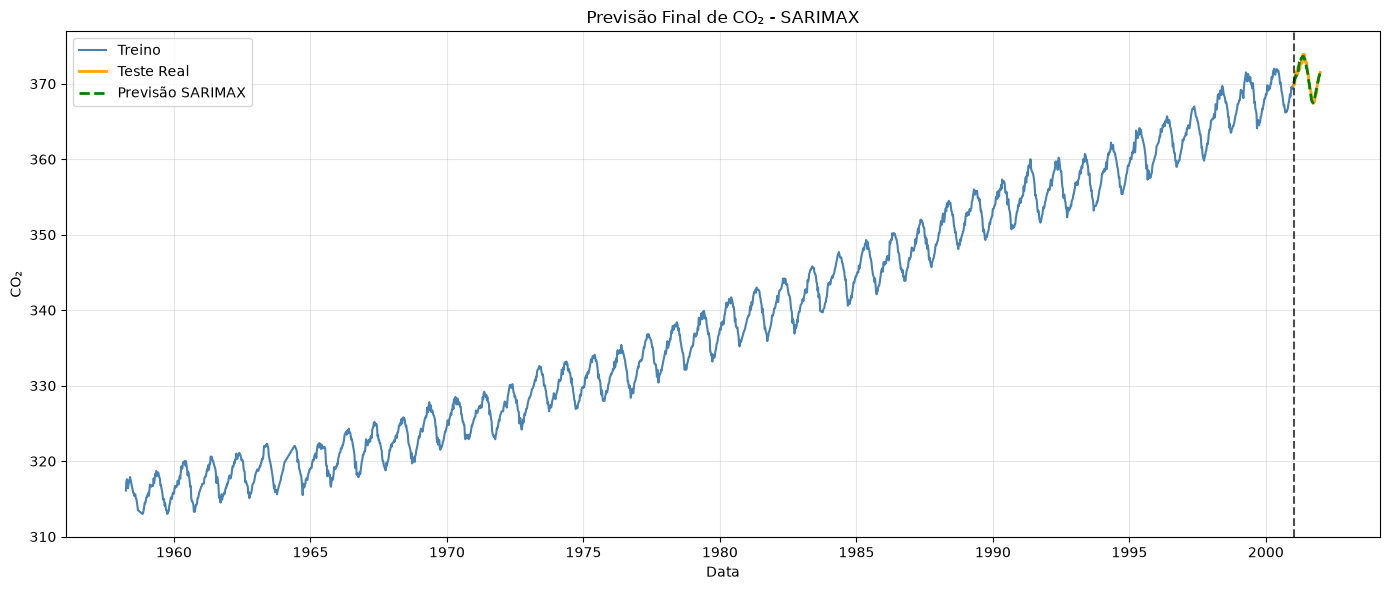

In [28]:
# Plotando gráficamente (dados modelagem + teste final)
plt.figure(figsize=(14,6))

plt.plot(dados_modelagem.index, dados_modelagem['co2'], color='steelblue', label='Treino', linewidth=1.5)
plt.plot(teste_final.index, teste_final['co2'], color='orange', label='Teste Real', linewidth=2)
plt.plot(previsoes_finais.index, previsoes_finais, color='green', label='Previsão SARIMAX', linestyle='--', linewidth=2)

plt.axvline(teste_final.index.min(), color='black', linestyle='--', alpha=0.7)
plt.title("Previsão Final de CO₂ - SARIMAX")
plt.xlabel("Data")
plt.ylabel("CO₂")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

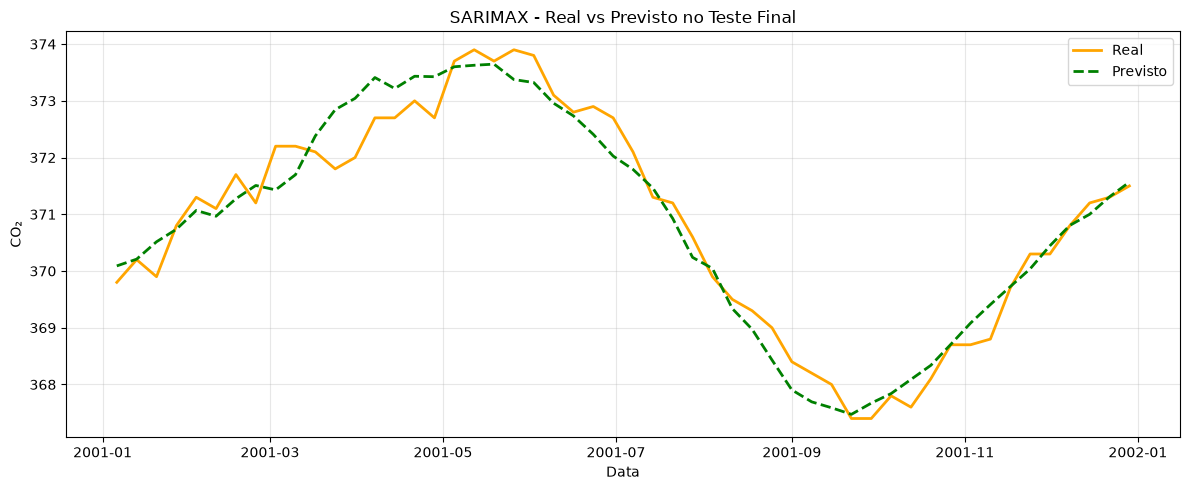

In [29]:
# Plotando o Gráfico do teste final + previsões
plt.figure(figsize=(12,5))

plt.plot(teste_final.index, teste_final['co2'], color='orange', label="Real", linewidth=2)
plt.plot(previsoes_finais.index, previsoes_finais, color='green', label='Previsto', linestyle='--', linewidth=2)

plt.title("SARIMAX - Real vs Previsto no Teste Final")
plt.xlabel("Data")
plt.ylabel("CO₂")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusão do Modelo Final

O modelo **SARIMAX(1,1,1)(1,1,1,52)** apresentou bom desempenho no conjunto de teste final, com:

- **MAE:** 0,335
- **RMSE:** 0,421
- **MAPE:** 0,090%

Esses resultados indicam baixo erro de previsão e boa capacidade de generalização para dados que não foram utilizados durante o treinamento.

Visualmente, a curva prevista acompanha de forma consistente o comportamento real da série ao longo de praticamente todo o período de teste. O modelo conseguiu reproduzir o crescimento observado no início do ano, o pico sazonal em torno de maio e junho, a queda ao longo do segundo semestre e a recuperação no final do período.

Apesar de pequenas diferenças pontuais entre os valores reais e previstos, o SARIMAX capturou adequadamente a **tendência local, a amplitude das oscilações e o padrão sazonal anual** da concentração de CO₂.

Dessa forma, os resultados quantitativos e a análise visual reforçam a escolha do SARIMAX como o modelo final para geração das previsões futuras.

# 10. Geração de Valor e Aplicação do Modelo

Após a seleção do SARIMAX como modelo final, a etapa seguinte consiste em transformar as previsões em informações úteis para acompanhamento e tomada de decisão.

O objetivo é utilizar o forecast para:

- projetar o comportamento do CO₂ nas próximas 52 semanas;
- analisar a incerteza associada às previsões;
- identificar períodos de maior e menor concentração;
- acompanhar a evolução semanal esperada;
- comparar o próximo ciclo previsto com o último ano observado.

## 10.1 Treinamento do Modelo com Todo o Histórico

Após a validação no conjunto de teste final, o SARIMAX é treinado novamente utilizando toda a série histórica disponível.

Nesta etapa, o objetivo deixa de ser avaliar o modelo e passa a ser utilizar todo o conhecimento disponível para gerar previsões futuras.

In [30]:
modelo_producao = SARIMAX(
    dados['co2'],
    order=(1,1,1),
    seasonal_order=(1,1,1,52)
).fit()

c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\co2-forecasting-statistical-vs-ml\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\co2-forecasting-statistical-vs-ml\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)


## 10.2 Previsão das Próximas 52 Semanas

Como a série possui frequência semanal e apresenta sazonalidade anual, o modelo é utilizado para prever as próximas **52 semanas**.

Além da previsão pontual, também são obtidos os limites inferior e superior do intervalo de confiança, permitindo representar a incerteza associada ao forecast.

In [31]:
forecast = modelo_producao.get_forecast(
    steps=52
)

previsao = forecast.predicted_mean
intervalo = forecast.conf_int()

In [32]:
forecast_df = pd.DataFrame({
    "co2_previsto": previsao,
    "limite_inferior": intervalo.iloc[:, 0],
    "limite_superior": intervalo.iloc[:, 1]
})

forecast_df.head()

,co2_previsto,limite_inferior,limite_superior
2002-01-05,371.637727,370.892660,372.382795
2002-01-12,371.809423,370.966777,372.652068
2002-01-19,372.105313,371.216435,372.994191
2002-01-26,372.293076,371.370227,373.215925
2002-02-02,372.590483,371.637659,373.543306


## 10.3 Forecast e Intervalo de Confiança

A previsão futura é analisada juntamente com seu intervalo de confiança.

A linha central representa o comportamento esperado da concentração de CO₂, enquanto a faixa ao redor da previsão indica a incerteza do modelo ao longo do horizonte futuro.

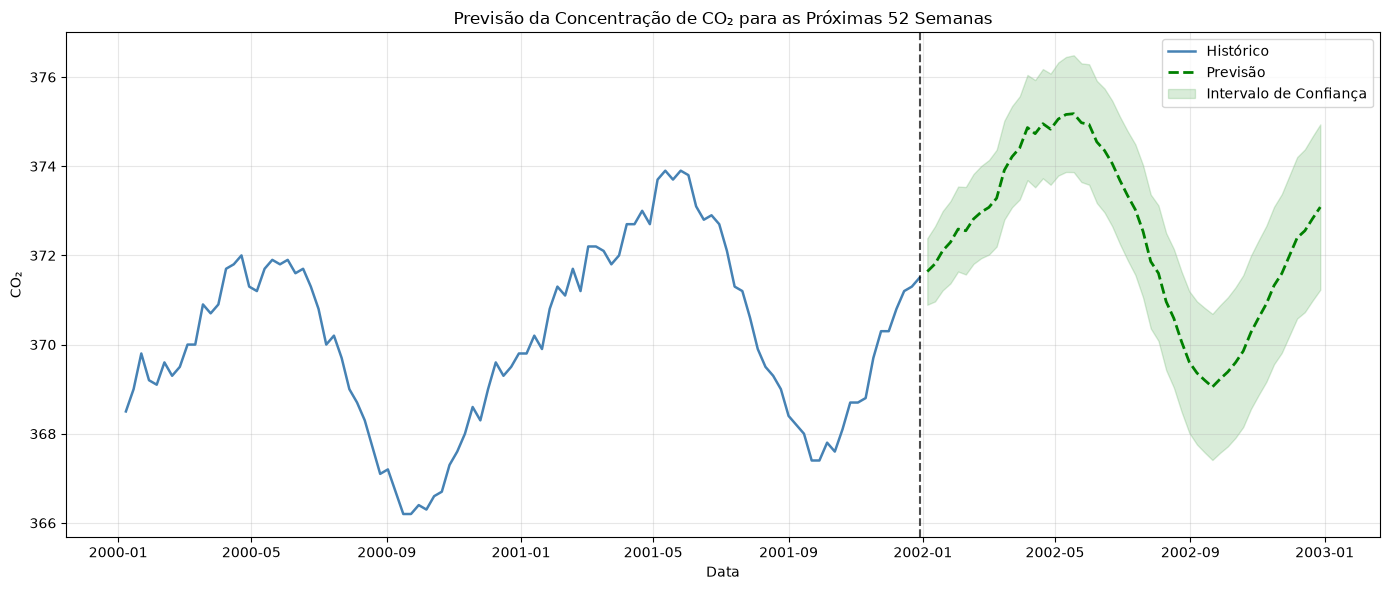

In [33]:
plt.figure(figsize=(14,6))

# Histórico recente
plt.plot(dados.index[-104:], dados['co2'].iloc[-104:], color='steelblue', label='Histórico', linewidth=1.8)

# Previsão
plt.plot(forecast_df.index, forecast_df['co2_previsto'], color='green', label='Previsão', linestyle='--', linewidth=2)

# Intervalo de confiança
plt.fill_between(
    forecast_df.index,
    forecast_df['limite_inferior'],
    forecast_df['limite_superior'],
    color='green',
    alpha=0.15,
    label='Intervalo de Confiança'
)

plt.axvline(dados.index.max(), color="black", linestyle="--", alpha=0.7)

plt.title("Previsão da Concentração de CO₂ para as Próximas 52 Semanas")
plt.xlabel("Data")
plt.ylabel("CO₂")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Observações

O forecast mantém o padrão observado historicamente, reproduzindo o crescimento no primeiro semestre, o pico sazonal, a redução ao longo do segundo semestre e a recuperação no final do ciclo.

O intervalo de confiança aumenta gradualmente ao longo do horizonte, refletindo a maior incerteza associada a previsões mais distantes no tempo.

## 10.4 Períodos de Maior e Menor Concentração Prevista

A partir das previsões, são identificadas as semanas com maior e menor concentração esperada de CO₂.

Essa análise permite destacar os principais pontos do próximo ciclo sazonal e resumir o comportamento esperado da série.

In [34]:
data_max = forecast_df['co2_previsto'].idxmax().date()
valor_max = forecast_df['co2_previsto'].max().round(2)

data_min = forecast_df['co2_previsto'].idxmin().date()
valor_min = forecast_df['co2_previsto'].min().round(2)

print(f"Maior concentração prevista -> {valor_max} em {data_max}")

print(f"Menor concentração prevista -> {valor_min} em {data_min}")

Maior concentração prevista -> 375.18 em 2002-05-18
Menor concentração prevista -> 369.05 em 2002-09-21


### Observações

O maior valor previsto de CO₂ é de aproximadamente **375,18**, estimado para **18/05/2002**.

Já o menor valor previsto é de aproximadamente **369,05**, estimado para **21/09/2002**.

Esses períodos são coerentes com o padrão sazonal identificado anteriormente na análise exploratória.

In [35]:
resumo_forecast = pd.DataFrame({
    "Indicador": [
        "Média prevista",
        "Máximo previsto",
        "Mínimo previsto"
    ],
    "Valor": [
        forecast_df["co2_previsto"].mean(),
        valor_max,
        valor_min
    ]
})

resumo_forecast.round(3)

,Indicador,Valor
0,Média prevista,372.42
1,Máximo previsto,375.18
2,Mínimo previsto,369.05


### Observações

A média prevista para o período é de aproximadamente **372,42**, com valores oscilando entre **369,05** e **375,18**.

Essa faixa resume o comportamento esperado da concentração de CO₂ ao longo do próximo ciclo anual.

## 10.6 Evolução Semanal Prevista

Além do nível previsto de CO₂, também é analisada a variação entre semanas consecutivas ao longo do horizonte de forecast.

Essa análise permite identificar períodos de crescimento, redução e maior estabilidade na concentração prevista.

O gráfico de variação semanal destaca visualmente esse comportamento:

* barras **verdes** representam semanas com aumento da concentração prevista;
* barras **vermelhas** representam semanas com redução;
* valores próximos de zero indicam maior estabilidade entre semanas consecutivas.




In [36]:
forecast_df["variacao_semanal"] = (forecast_df["co2_previsto"].diff())

forecast_df["variacao_pct"] = (forecast_df["co2_previsto"].pct_change() * 100)

forecast_df.head()

,co2_previsto,limite_inferior,limite_superior,variacao_semanal,variacao_pct
2002-01-05,371.637727,370.892660,372.382795,NaN,NaN
2002-01-12,371.809423,370.966777,372.652068,0.171695,0.046200
2002-01-19,372.105313,371.216435,372.994191,0.295891,0.079581
2002-01-26,372.293076,371.370227,373.215925,0.187763,0.050460
2002-02-02,372.590483,371.637659,373.543306,0.297407,0.079885


In [37]:
maior_alta = forecast_df["variacao_semanal"].idxmax()
maior_queda = forecast_df["variacao_semanal"].idxmin()

print(
    f"Maior aumento semanal -> "
    f"{forecast_df.loc[maior_alta, 'variacao_semanal']:.3f} "
    f"em {maior_alta.date()}"
)

print(
    f"Maior redução semanal -> "
    f"{forecast_df.loc[maior_queda, 'variacao_semanal']:.3f} "
    f"em {maior_queda.date()}"
)

Maior aumento semanal -> 0.628 em 2002-03-16
Maior redução semanal -> -0.677 em 2002-07-27


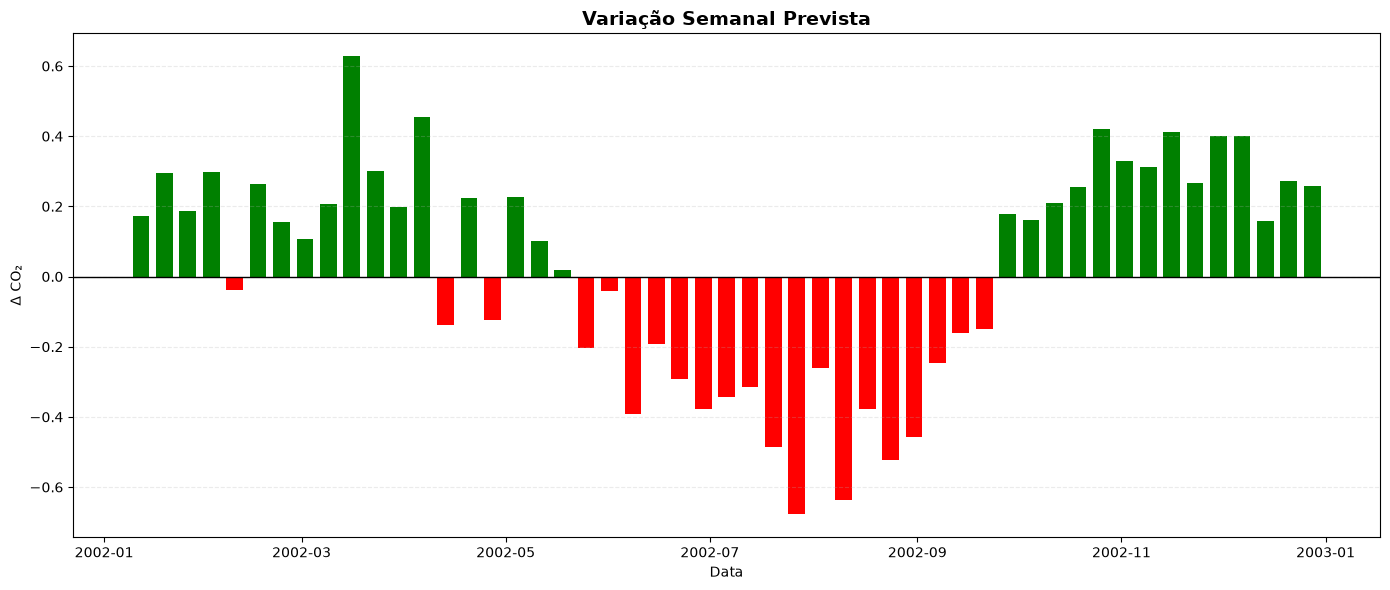

In [45]:
# Definindo as cores das barras
cores = [
    "green" if valor >= 0 else "red"
    for valor in forecast_df['variacao_semanal'].fillna(0)
]

plt.figure(figsize=(14, 6))

plt.bar(forecast_df.index, forecast_df['variacao_semanal'], color=cores, width=5)

plt.axhline(0, color='black', linewidth=1)

plt.title("Variação Semanal Prevista", fontsize=14, fontweight="bold")
plt.xlabel("Data")
plt.ylabel("Δ CO₂")
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.tight_layout()
plt.show()

### Observações

A maior alta semanal prevista é de aproximadamente **0,628**, registrada em **16/03/2002**.

A maior redução semanal prevista é de aproximadamente **-0,677**, registrada em **27/07/2002**.

Visualmente, observa-se um período predominante de crescimento entre janeiro e maio, seguido por uma sequência de reduções ao longo do meio do ano. A partir do final de setembro, o comportamento volta a ser predominantemente positivo.

Esse padrão acompanha o ciclo sazonal identificado anteriormente na série, evidenciando como a concentração prevista de CO₂ varia ao longo do ano.

## 10.7 Comparação com o Último Ano Observado

Para contextualizar as previsões, a média esperada para as próximas 52 semanas é comparada com a média observada nas últimas 52 semanas da série histórica.

Essa comparação permite avaliar se o modelo projeta crescimento, redução ou estabilidade no nível médio de CO₂.

In [38]:
ultimo_ano = dados['co2'].iloc[-52:]

media_ultimo_ano = ultimo_ano.mean()
media_prevista = forecast_df['co2_previsto'].mean()

variacao_absoluta = (media_prevista - media_ultimo_ano)

variacao_percentual = (variacao_absoluta / media_ultimo_ano) * 100

print(f"Média último ano observado -> {media_ultimo_ano:.3f}")
print(f"Média prevista próximo ano -> {media_prevista:.3f}")
print(f"Variação absoluta -> {variacao_absoluta:.3f}")
print(f"Variação percentual -> {variacao_percentual:.3f}%")

Média último ano observado -> 370.865
Média prevista próximo ano -> 372.420
Variação absoluta -> 1.554
Variação percentual -> 0.419%


In [39]:
comparacao_anual = pd.DataFrame({
    "Período" : ["Último Ano", "Próximo Ano Previsto"],
    "CO₂ Médio": [media_ultimo_ano, media_prevista]
})

comparacao_anual.round(3)

,Período,CO₂ Médio
0,Último Ano,370.865
1,Próximo Ano Previsto,372.420


### Observações

A média observada no último ano foi de aproximadamente **370,87**, enquanto a média prevista para o próximo ano é de **372,42**.

Isso representa um aumento absoluto de aproximadamente **1,55** e uma variação percentual de cerca de **0,42%**.

O resultado indica que o modelo projeta continuidade da tendência crescente da concentração atmosférica de CO₂ no próximo ciclo anual.

# 11. Exportação do Modelo Final — SARIMAX

Após a validação e geração das previsões futuras, o modelo SARIMAX treinado com todo o histórico disponível é serializado para utilização fora do notebook.

A exportação permite reutilizar o modelo diretamente em aplicações, como uma interface desenvolvida em Streamlit, sem a necessidade de realizar um novo treinamento a cada execução.

In [41]:
import joblib

joblib.dump(modelo_producao, "sarimax_final.pkl")

print("Modelo salvo com sucesso!!")

Modelo salvo com sucesso!!


# Conclusão Final

Este projeto teve como objetivo analisar e prever a concentração atmosférica de CO₂ por meio de técnicas clássicas de séries temporais e modelos de Machine Learning.

Inicialmente, os dados passaram por uma etapa de validação e tratamento, garantindo a consistência do índice temporal, a ausência de duplicidades e o preenchimento dos valores ausentes por interpolação temporal. Em seguida, a análise exploratória revelou uma **tendência crescente de longo prazo**, acompanhada por uma **sazonalidade anual bem definida**.

A análise de estacionariedade mostrou que a série original não era estacionária. Após a aplicação de diferenciação regular e sazonal, a série passou a apresentar comportamento mais adequado para modelagem, resultado confirmado pelo teste ADF.

Na etapa de modelagem, foram avaliadas diferentes abordagens:

- Holt-Winters;
- SARIMAX;
- Random Forest;
- XGBoost.

Os modelos foram comparados utilizando validação temporal com `TimeSeriesSplit`, preservando a ordem cronológica dos dados. Os modelos de Machine Learning também passaram por uma etapa de otimização de hiperparâmetros com `RandomizedSearchCV`.

Mesmo após o tuning, o **SARIMAX(1,1,1)(1,1,1,52)** apresentou o melhor desempenho geral, obtendo os menores valores médios de MAE, RMSE e MAPE durante a validação.

No conjunto de teste final, reservado exclusivamente para avaliação, o modelo apresentou:

- **MAE:** 0,335
- **RMSE:** 0,421
- **MAPE:** 0,090%

Além dos bons resultados quantitativos, a previsão acompanhou visualmente de forma consistente o comportamento real da série, capturando o ciclo sazonal, os períodos de alta e baixa concentração e a evolução ao longo do ano.

Por fim, o modelo foi treinado com todo o histórico disponível para gerar previsões das próximas 52 semanas. O forecast indicou continuidade do padrão sazonal e da tendência de crescimento observada historicamente, permitindo também identificar máximos, mínimos, variações semanais e a evolução média esperada para o próximo ciclo anual.

O projeto demonstra que modelos estatísticos clássicos podem apresentar excelente desempenho em séries temporais univariadas com estrutura temporal bem definida. Mais do que selecionar o algoritmo mais complexo, os resultados reforçam a importância de compreender a série, respeitar sua estrutura temporal e utilizar uma estratégia adequada de validação.

Como evolução futura, o projeto pode ser expandido com variáveis exógenas, novos modelos de forecasting, automação do pipeline de treinamento e construção de dashboards ou sistemas de monitoramento preditivo.